
# Praktikum: Logistic Regression

Nama: Muhammad 'Azmi Salam 

NIM: 2406010  

## Instruksi
- Implementasikan semua bagian TODO.
- Jangan menghapus cell yang diberi komentar **DO NOT MODIFY**.
- Restart & Run All sebelum submit.
- Submit file `.ipynb` dan `.html` melalui SPADA.
- Penamaan file: NIM_NAMA_logreg.[html/ipynb]

In [ ]:
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support, accuracy_score

np.random.seed(42)


## Persiapan Data


In [ ]:
def add_bias(x):
  bias = np.ones(x.shape[0])
  return np.c_[bias, x]

In [ ]:
data = pd.read_csv("https://drive.google.com/uc?id=1PoIx2WWiG7fjkxKHzFcSDf8xSOIxjU0F")

In [ ]:
X = data[["size"]].to_numpy()
X = X / X.max(axis=0)
X = add_bias(X)
y = data[["y"]].to_numpy().reshape(X.shape[0])

print("Shape X:", X.shape)
print("Rasio Malignant/Benign:", y.mean())


Shape X: (80, 2)
Rasio Malignant/Benign: 0.5



## TODO 1: Implementasikan Sigmoid Function

$
\begin{aligned}
sigmoid(z) = \frac{1}{1 + e^{-z}}
\end{aligned}
$


In [ ]:

def sigmoid(z):
    # TODO: implementasikan sigmoid
    return 1/(1+math.e**-z)


In [ ]:

# ================================
# SELF TEST - DO NOT MODIFY
# ================================
def _test_sigmoid():
    assert abs(sigmoid(0) - 0.5) < 1e-6
    assert sigmoid(10) > 0.99
    assert sigmoid(-10) < 0.01

_test_sigmoid()



## TODO 2: Implementasikan Log-Loss
$
loss(w) = - \frac{1}{m} \left[
\sum_{i=1}^{m} y^{(i)} \log h_w(x^{(i)})+ (1 - y^{(i)}) \log \left(1 - h_w(x^{(i)})\right)
\right]
$

In [ ]:

def log_loss(y, pred):
    # TODO: implementasikan log-loss
    m = len(y)

    # clip pred agar tidak kenal log(0) yang hasilnya -inf
    pred = np.clip(pred, 1e-15, 1 - 1e-15)

    loss = -1/m * np.sum(y * np.log(pred) + (1 - y) * np.log(1 - pred))

    return loss



In [ ]:

# ================================
# SELF TEST - DO NOT MODIFY
# ================================
def _test_logloss():
    y_test = np.array([1,0,1,0])
    a_test = np.array([0.9,0.1,0.8,0.2])
    loss = log_loss(y_test, a_test)
    assert loss > 0
    assert log_loss(np.array([1]), np.array([0.99])) < log_loss(np.array([1]), np.array([0.1]))

_test_logloss()



## TODO 3: Implementasikan Predict dan Gradient untuk Update Bobot
$
\frac{\partial J(w)}{\partial w_j}
= \frac{1}{m}\sum_{i=1}^{m}\left(h_w(x^{(i)}) - y^{(i)}\right)\,x_j^{(i)}
$



In [ ]:
def predict(w, x):
  # TODO: implementasikan fungsi prediksi h(x)
  return sigmoid(x @ w)

In [ ]:

def update_bobot(w,xb,y,alpha):
    # TODO: implementasikan update bobot
    m = len(y)

    # hitung prediksi untuk semua data sekaligus
    y_pred = np.array([predict(w, x) for x in xb])

    error = y_pred - y
    gradient = (1/m) * (xb.T @ error)

    w = w - alpha * gradient

    return w



In [ ]:

# ================================
# SELF TEST - DO NOT MODIFY
# ================================
def _hidden_test_gradient():
    w_test = np.zeros(X.shape[1])
    w = update_bobot(w_test,X, y, 0.001)
    assert w.shape == w_test.shape
    assert not np.isnan(w).any()

_hidden_test_gradient()



## Training dengan Gradient Descent


Bobot Akhir: [-2.30190552  4.75205009]
Loss Akhir: 0.325635473493011


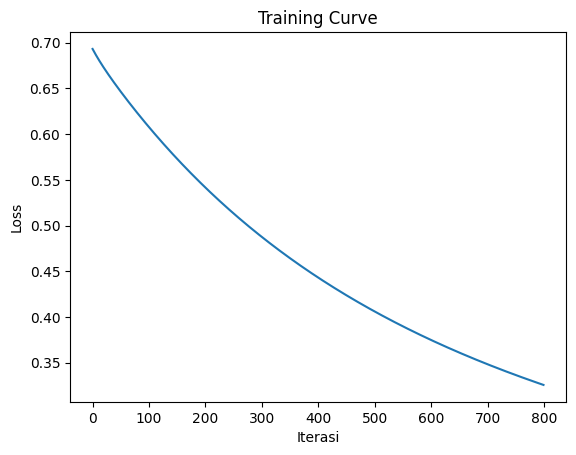

In [ ]:

def train(X, y, alpha=0.1, iters=500):
    w = np.zeros(X.shape[1])
    history = []

    for i in range(iters):
        pred = predict(w, X)
        loss = log_loss(y, pred)
        history.append(loss)
        w = update_bobot(w, X, y, alpha)

    return w, np.array(history)

w, hist = train(X, y, alpha=0.1, iters=800)

print("Bobot Akhir:", w)
print("Loss Akhir:", hist[-1])

plt.plot(hist)
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.title("Training Curve")
plt.show()



## Evaluasi (Threshold = 0.5)


In [ ]:

def predict_label(X, w, t=0.5):
    return (predict(w, X) >= t).astype(int)

y_pred = predict_label(X, w, t=0.5)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)
pr, rc, f1, _ = precision_recall_fscore_support(y, y_pred, average='binary')

print("Confusion Matrix:\n", cm)
print("Accuracy:", acc)
print("Precision:", pr)
print("Recall:", rc)
print("F1:", f1)


Confusion Matrix:
 [[39  1]
 [ 0 40]]
Accuracy: 0.9875
Precision: 0.975609756097561
Recall: 1.0
F1: 0.9876543209876543



## Analisis Singkat (WAJIB DIISI)

1. Apa arti probabilitas 0.6 dibanding 0.95?
2. Apa efek menaikkan threshold menjadi 0.7?
3. Mengapa gradient berbentuk (a − y)?

Jawab dalam 3–5 kalimat.


Jawaban:
1. probabilitas 0.6 artinya model cukup yakin dengan sampel positif karena sudah diatas 0.5, tetapi masih ada ketidakpastian yang cukup besar. Sedangkan 0.95 berarti model sudah sangat yakin bahwa sampel tersebut posisif. Jadi semakin tinggi probabilitas, semakin kuat keyakinan model terhadap prediksinya. 

2. Dengan threshold lebih tinggi, model akan lebih "ketat" dalam mengklasifikasikan sampel sebagai positif hanya sampel dengan probabilitas ≥0.7 yang dianggap positif. Ini cenderung menurunkan recall (lebih banyak false negative) namun meningkatkan precision (lebih sedikit false positive).

3. Bentuk $(h_w(x) - y)$ merupakan turunan parsial dari log-loss terhadap bobot $w$. Ini berarti, jika prediksi ($a$) lebih besar dari label asli ($y$), gradient positif dan bobot dikurangi. Sebaliknya, jika prediksi terlalu rendah, bobot ditambah. Ini secara otomatis mengarahkan update bobot ke arah yang meminimalkan loss.